In [4]:
# -------- Imports & optional install ----------
import sys
import os
import re
import numpy as np
import pandas as pd
from pathlib import Path
import csv
csv.field_size_limit(10**9)

# If tensorflow is not installed, uncomment the following line to install (may take some minutes)
# !{sys.executable} -m pip install tensorflow-cpu

# Common libs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Text tools
import nltk
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt", quiet=True)
try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words("english"))

# Try importing tensorflow and Keras (raises helpful error if not installed)
try:
    import tensorflow as tf
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, SpatialDropout1D, Bidirectional, LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except Exception as e:
    raise ImportError(
        "tensorflow (or Keras) could not be imported. "
        "Install it (recommended `pip install tensorflow-cpu`) and re-run the cell."
    ) from e

# -------- Helper functions ----------
def basic_clean(text):
    """Lowercase, remove emails/urls/punctuation, remove stopwords."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [t for t in text.split() if t not in STOPWORDS]
    return " ".join(tokens)

def detect_text_and_label_columns(df):
    text_candidates = [c for c in df.columns if any(k in c.lower() for k in ("text","message","body","mail","content","message_text","v2","email"))]
    label_candidates = [c for c in df.columns if any(k in c.lower() for k in ("label","spam","class","v1","target"))]
    text_col = text_candidates[0] if text_candidates else None
    label_col = label_candidates[0] if label_candidates else None
    return text_col, label_col

# -------- Data loading (paths you gave) ----------
paths = ["spam/enron_spam_data.csv", "spam/spam.csv", "spam/spam_assassin.csv"]

dfs = []
for p in paths:
    if os.path.exists(p):
        try:
            tmp = pd.read_csv(p, encoding="utf-8", engine="python")
        except Exception:
            tmp = pd.read_csv(p, encoding="latin-1", engine="python")
        print(f"Loaded: {p} -> shape={tmp.shape}")
        dfs.append((p, tmp))
    else:
        print(f"Not found: {p}")

# -------- Normalize + preprocess each df ----------
frames = []
for fname, df in dfs:
    text_col, label_col = detect_text_and_label_columns(df)
    if text_col is None:
        # fallback: pick the most textual object column
        text_like = [c for c in df.columns if df[c].dtype == object]
        if text_like:
            text_col = max(text_like, key=lambda c: df[c].astype(str).str.len().median())
    if label_col is None:
        # fallback: try to find spam/ham-like column
        for c in df.columns:
            vals = set(df[c].astype(str).str.lower().unique()[:20])
            if vals & {"spam","ham","1","0","true","false","junk","notspam","spam "," ham"}:
                label_col = c
                break
    if text_col is None or label_col is None:
        print(f"Skipping {fname}: couldn't detect text/label columns (text={text_col}, label={label_col})")
        continue
    tmp = df[[text_col, label_col]].rename(columns={text_col: "text", label_col: "label"}).copy()
    tmp["label"] = tmp["label"].astype(str).str.lower().map(lambda v: "spam" if ("spam" in v or v in ("1","true","t","y","yes")) else "ham")
    tmp["text"] = tmp["text"].apply(basic_clean)
    frames.append(tmp)

if not frames:
    raise RuntimeError("No usable datasets after column detection. Ensure CSVs contain recognizable text and label columns.")

data = pd.concat(frames, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print("Combined data shape:", data.shape)
print(data["label"].value_counts())

# (Optional) show a peek
display(data.head())

# -------- Tokenize & prepare sequences ----------
MAX_VOCAB = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(data["text"].values)
sequences = tokenizer.texts_to_sequences(data["text"].values)
X = pad_sequences(sequences, maxlen=MAX_LEN, padding="post", truncating="post")

le = LabelEncoder()
y = le.fit_transform(data["label"].values)  # ham/spam -> 0/1

print("X shape:", X.shape, "Class dist:", np.bincount(y))

# -------- Train/test split ----------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


Loaded: spam/enron_spam_data.csv -> shape=(33716, 5)
Loaded: spam/spam.csv -> shape=(5572, 5)
Loaded: spam/spam_assassin.csv -> shape=(5796, 2)
Combined data shape: (45084, 2)
label
ham     25270
spam    19814
Name: count, dtype: int64


,text,label
0,start date 2 6 02 hourahead hour 24 ancillary ...,spam
1,message sent pjm customer info mailing list pj...,ham
2,dear vincent kaminski welcome energy news live...,ham
3,attached latest version cost center assignment...,spam
4,anything specific regards jaklin idk fuck,ham


X shape: (45084, 200) Class dist: [25270 19814]


In [5]:
# -------- Build model (>=7 layers) ----------
vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
embed_dim = 128

model = Sequential(name="SpamClassifier_Embedding_BiLSTM")
# 1) Embedding
model.add(Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=MAX_LEN, name="embedding"))
# 2) SpatialDropout1D
model.add(SpatialDropout1D(0.2, name="spatial_dropout"))
# 3) Bi-LSTM (return seq)
model.add(Bidirectional(LSTM(128, return_sequences=True), name="bilstm_1"))
# 4) Bi-LSTM
model.add(Bidirectional(LSTM(64), name="bilstm_2"))
# 5) Dense
model.add(Dense(64, activation="relu", name="dense_64"))
# 6) Dropout
model.add(Dropout(0.3, name="dropout_1"))
# 7) Dense
model.add(Dense(32, activation="relu", name="dense_32"))
# 8) Dropout
model.add(Dropout(0.2, name="dropout_2"))
# 9) Output
model.add(Dense(1, activation="sigmoid", name="output"))

model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

# -------- Train ----------
EPOCHS = 8
BATCH_SIZE = 64

callbacks = [EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]

history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


C:\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "SpamClassifier_Embedding_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout (SpatialDropout1D)   │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bilstm_1 (Bidirectional)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bilstm_2 (Bidirectional)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_64 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 338s 693ms/step - accuracy: 0.9672 - loss: 0.1061 - val_accuracy: 0.9915 - val_loss: 0.0281
Epoch 2/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 419s 770ms/step - accuracy: 0.9918 - loss: 0.0277 - val_accuracy: 0.9904 - val_loss: 0.0346
Epoch 3/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 399s 834ms/step - accuracy: 0.9946 - loss: 0.0177 - val_accuracy: 0.9932 - val_loss: 0.0241
Epoch 4/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 414s 776ms/step - accuracy: 0.9968 - loss: 0.0122 - val_accuracy: 0.9937 - val_loss: 0.0255
Epoch 5/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 389s 791ms/step - accuracy: 0.9978 - loss: 0.0089 - val_accuracy: 0.9946 - val_loss: 0.0237
Epoch 6/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 398s 824ms/step - accuracy: 0.9982 - loss: 0.0073 - val_accuracy: 0.9948 - val_loss: 0.0255
Epoch 7/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 449s 838ms/step - accuracy: 0.9989 - loss: 0.0044 - val_accuracy: 0.9950 - val_loss: 0.0272
Epoch 8/8
479/479 ━━━━━━━━━━━━━━━━━━━━ 448s 851ms/step - accuracy: 0.9990 - loss: 0

Test loss: 0.0240, Test accuracy: 0.9938
282/282 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step

Classification report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      5054
        spam       1.00      0.99      0.99      3963

    accuracy                           0.99      9017
   macro avg       0.99      0.99      0.99      9017
weighted avg       0.99      0.99      0.99      9017

ROC AUC: 0.9991
Confusion matrix:
[[5043   11]
 [  45 3918]]


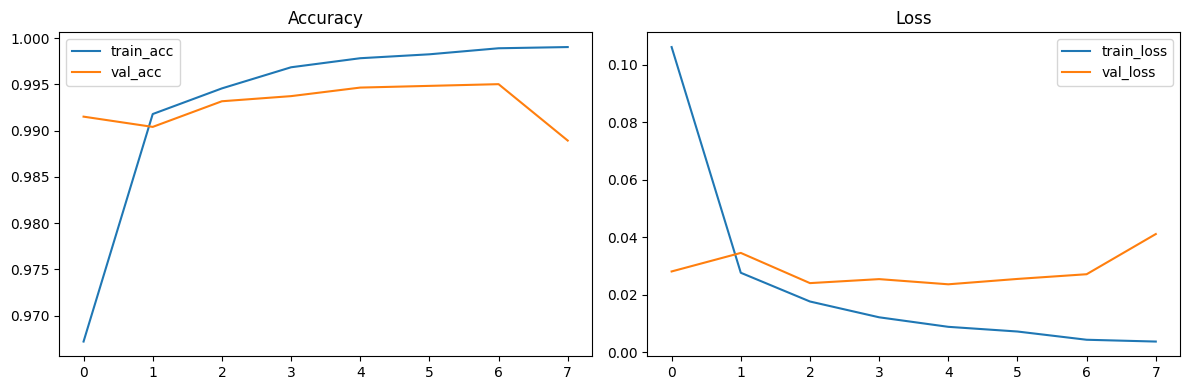

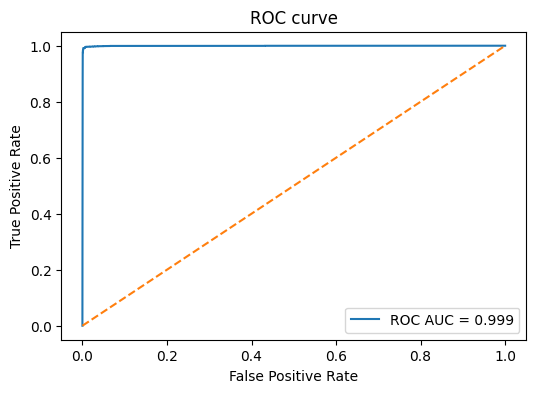

Saved model and tokenizer to: ./spam_model_artifacts


In [6]:
# -------- Evaluate ----------
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {loss:.4f}, Test accuracy: {acc:.4f}")

y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

try:
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f"ROC AUC: {auc:.4f}")
except Exception:
    pass

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

# -------- Plots: training curves & ROC ----------
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history["accuracy"], label="train_acc")
ax[0].plot(history.history["val_accuracy"], label="val_acc")
ax[0].set_title("Accuracy")
ax[0].legend()

ax[1].plot(history.history["loss"], label="train_loss")
ax[1].plot(history.history["val_loss"], label="val_loss")
ax[1].set_title("Loss")
ax[1].legend()
plt.tight_layout()
plt.show()

try:
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_pred_prob):.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title("ROC curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()
except Exception as e:
    print("Could not plot ROC:", e)

# -------- Save artifacts ----------
out_dir = "./spam_model_artifacts"
Path(out_dir).mkdir(parents=True, exist_ok=True)
# Save tokenizer
with open(os.path.join(out_dir, "tokenizer.json"), "w", encoding="utf-8") as f:
    f.write(tokenizer.to_json())
# Save model (HDF5)
model.save(os.path.join(out_dir, "spam_classifier_model.h5"))
print("Saved model and tokenizer to:", out_dir)


In [7]:
# -------- Helper: predict on new texts ----------
def predict_texts(texts, threshold=0.5):
    cleaned = [basic_clean(t) for t in texts]
    seq = tokenizer.texts_to_sequences(cleaned)
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    probs = model.predict(pad).ravel()
    labels = ["spam" if p >= threshold else "ham" for p in probs]
    return pd.DataFrame({"text": texts, "cleaned": cleaned, "prob_spam": probs, "pred_label": labels})


In [8]:
# Demo predictions
demo = predict_texts([
    "Congratulations! You've won a free iPhone. Click here to claim.",
    "Could we reschedule today's meeting to 3pm?"
])
display(demo)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


,text,cleaned,prob_spam,pred_label
0,Congratulations! You've won a free iPhone. Cli...,congratulations free iphone click claim,0.656712,spam
1,Could we reschedule today's meeting to 3pm?,could reschedule today meeting 3pm,0.000010,ham
